# Atelier Préparation de Données Textuelles

## Contexte 

Une entreprise souhaite développer un système capable de classer automatiquement des avis clients afin d'identifier leur sentiment. Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, réseaux sociaux et service client. Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent donc construire un pipeline complet de préparation des données textuelles. 

## Partie 1 – Exploration du corpus

### 1) Charger les données CSV ; 

In [1]:
import pandas as pd

df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### 2) Combien d'avis contient le dataset ? 

In [2]:
nb_avis = df.shape[0]
print(f"Nombre d'avis : {nb_avis}")

Nombre d'avis : 1200


### 3) Combien de colonnes possède-t-il ?

In [3]:
nb_colonnes = df.shape[1]
print(f"Nombre de colonnes : {nb_colonnes}")

Nombre de colonnes : 8


### 4) Quel est le type de chaque colonne ?

In [4]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 5) Existe-t-il des valeurs manquantes ? 

In [5]:
df.isnull().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

### 6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères. 

In [7]:
import re

# Texte normal (premier avis sans rien de particulier)
print("Texte normal :", df.loc[0, "texte"])

# Texte vide (valeur manquante)
print("Texte vide :", df[df["texte"].isnull()]["texte"].head(1).values)

# Texte contenant une URL
print("Avec URL :", df[df["texte"].str.contains(r"http\S+", na=False)]["texte"].iloc[0])

# Texte contenant une mention (@quelquechose)
print("Avec mention :", df[df["texte"].str.contains(r"@\w+", na=False)]["texte"].iloc[0])

# Texte contenant un hashtag (#quelquechose)
print("Avec hashtag :", df[df["texte"].str.contains(r"#\w+", na=False)]["texte"].iloc[0])

# Texte contenant des emojis
print("Avec emoji :", df[df["texte"].str.contains(r"[\U0001F300-\U0001FAFF]", na=False, regex=True)]["texte"].iloc[0])

# Texte avec beaucoup de ponctuation
print("Beaucoup de ponctuation :", df[df["texte"].str.contains(r"[!?]{2,}", na=False)]["texte"].iloc[0])

# Texte en majuscules
print("En majuscules :", df[df["texte"].str.isupper() == True]["texte"].iloc[0])

# Texte avec répétition de caractères (version sans warning)
pattern_repetition = re.compile(r"(.)\1{2,}")
mask_repetition = df["texte"].apply(lambda t: bool(pattern_repetition.search(t)) if pd.notna(t) else False)
print("Répétition de caractères :", df[mask_repetition]["texte"].iloc[0])

Texte normal : Très  bonne  expérience,  simple  et  efficace.
Texte vide : <StringArray>
[nan]
Length: 1, dtype: str
Avec URL : Produit parfait, rien à signaler. https://example.com/commande/17
Avec mention : @client Livraison rapide et produit conforme à mes attentes.
Avec hashtag : Très satisfait de mon achat 👍 #avis
Avec emoji : Très satisfait de mon achat 👍 #avis
Beaucoup de ponctuation : Produit excellent, je suis très satisfait. !!!
En majuscules : LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
Répétition de caractères : Produit excellent, je suis très satisfait. !!!


### 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles. 

In [8]:
df["longueur"] = df["texte"].apply(lambda t: len(t.split()) if pd.notna(t) else 0)

longueur_min = df["longueur"].min()
longueur_max = df["longueur"].max()
longueur_moyenne = df["longueur"].mean()
longueur_mediane = df["longueur"].median()
quartiles = df["longueur"].quantile([0.25, 0.5, 0.75])

print(f"Longueur minimale : {longueur_min}")
print(f"Longueur maximale : {longueur_max}")
print(f"Longueur moyenne : {longueur_moyenne:.2f}")
print(f"Longueur médiane : {longueur_mediane}")
print("Quartiles :\n", quartiles)

Longueur minimale : 0
Longueur maximale : 120
Longueur moyenne : 6.96
Longueur médiane : 7.0
Quartiles :
 0.25    6.0
0.50    7.0
0.75    8.0
Name: longueur, dtype: float64


### 8) Visualiser la distribution de la longueur des avis puis répondre aux questions 

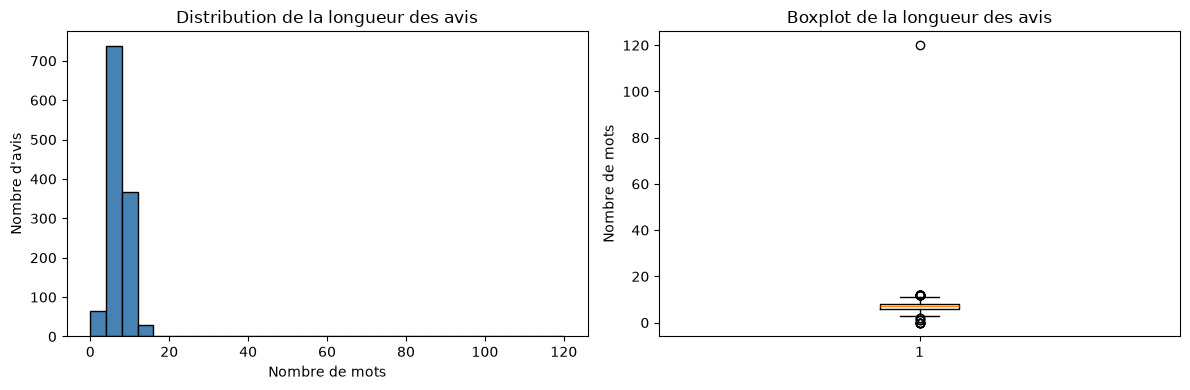

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
axes[0].hist(df["longueur"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution de la longueur des avis")
axes[0].set_xlabel("Nombre de mots")
axes[0].set_ylabel("Nombre d'avis")

# Boxplot
axes[1].boxplot(df["longueur"], orientation="vertical")
axes[1].set_title("Boxplot de la longueur des avis")
axes[1].set_ylabel("Nombre de mots")

plt.tight_layout()
plt.show()

### Analyse de la distribution de la longueur des avis

**a) Existe-t-il des textes anormalement longs ?**

Oui. Le boxplot fait apparaître des points isolés (outliers) nettement au-dessus de la 
moustache supérieure, correspondant à des avis atteignant jusqu'à 120 mots, alors que la 
médiane n'est que de 7 mots. Ces avis très longs sortent clairement du comportement habituel 
du corpus.

**b) Existe-t-il beaucoup de textes très courts ?**

Oui, très majoritairement. L'histogramme montre une barre très haute (plus de 700 avis) 
concentrée dans la tranche 0-20 mots, ce qui confirme que la quasi-totalité des avis du 
dataset sont courts. Le reste des valeurs s'étale ensuite en une longue traîne peu peuplée 
jusqu'à 120 mots.

### 9) Détecter les textes vides 

In [12]:
# Textes manquants (NaN)
textes_nan = df["texte"].isnull().sum()

# Textes vides ou uniquement des espaces (mais pas NaN)
textes_vides_str = df["texte"].apply(lambda t: isinstance(t, str) and t.strip() == "").sum()

print(f"Textes NaN : {textes_nan}")
print(f"Textes vides (chaîne vide ou espaces) : {textes_vides_str}")
print(f"Total textes vides (les deux cas) : {textes_nan + textes_vides_str}")

Textes NaN : 5
Textes vides (chaîne vide ou espaces) : 1
Total textes vides (les deux cas) : 6


### 10) Détecter les doublons sur le texte

In [13]:
nb_doublons = df["texte"].duplicated().sum()
print(f"Nombre de textes en doublon : {nb_doublons}")

# Afficher quelques exemples de doublons
doublons = df[df["texte"].duplicated(keep=False)].sort_values("texte")
doublons[["id_avis", "source", "texte"]].head(10)

Nombre de textes en doublon : 881


,id_avis,source,texte
312,AV0313,mobile,@client Excellent rapport qualité-prix.
419,AV0420,sav,@client Excellent rapport qualité-prix.
1099,AV1100,email,@client Excellent rapport qualité-prix.
45,AV0046,web,@client Excellent rapport qualité-prix.
466,AV0467,mobile,@client Excellent rapport qualité-prix.
1059,AV1060,email,@client Excellent rapport qualité-prix.
146,AV0147,mobile,@client Excellent rapport qualité-prix.
593,AV0594,mobile,@client Excellent rapport qualité-prix.
611,AV0612,web,@client Excellent rapport qualité-prix.
398,AV0399,email,@client Excellent rapport qualité-prix.


### 11) Les classes sont-elles équilibrées ? 

In [14]:
repartition_sentiment = df["sentiment"].value_counts()
print(repartition_sentiment)

# En pourcentage, plus parlant pour juger de l'équilibre
repartition_pct = df["sentiment"].value_counts(normalize=True) * 100
print("\nEn pourcentage :")
print(repartition_pct.round(2))

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

En pourcentage :
sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64


### 12) Quelle est la classe majoritaire ? 

In [15]:
classe_majoritaire = df["sentiment"].value_counts().idxmax()
part_majoritaire = df["sentiment"].value_counts(normalize=True).max() * 100

print(f"Classe majoritaire : {classe_majoritaire} ({part_majoritaire:.2f}% des avis)")

Classe majoritaire : positif (64.67% des avis)


### 13) Quelles métriques de classification à envisager d’utiliser ? 

### Métriques de classification à envisager

Le dataset étant déséquilibré (positif = 64.67%, neutre = 20.50%, negatif = 14.83%), 
l'**accuracy seule n'est pas fiable** : un modèle naïf qui prédit toujours "positif" 
atteindrait déjà ~65% d'accuracy sans avoir rien appris.

Il est donc préférable de privilégier :
- **Precision** et **recall** par classe, pour évaluer la qualité des prédictions sur 
  chaque catégorie, y compris les minoritaires (`negatif`, `neutre`)
- **F1-score macro** : moyenne des F1-scores de chaque classe sans pondération, pour 
  éviter que la classe majoritaire n'écrase l'évaluation
- **Matrice de confusion** : pour visualiser précisément quelles classes sont confondues 
  entre elles

### 14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères spéciaux ; ponctuation répétée ; … 

In [16]:
import re

patterns = {
    "URLs": re.compile(r"http\S+"),
    "Mentions": re.compile(r"@\w+"),
    "Hashtags": re.compile(r"#\w+"),
    "Emojis": re.compile(r"[\U0001F300-\U0001FAFF]"),
    "Chiffres": re.compile(r"\d"),
    "Caractères spéciaux": re.compile(r"[^\w\s.,!?'\-]"),
    "Ponctuation répétée": re.compile(r"([!?.]){2,}"),
}

resultats = {}
for nom, pattern in patterns.items():
    nb_avis_concernes = df["texte"].apply(
        lambda t: bool(pattern.search(t)) if pd.notna(t) else False
    ).sum()
    resultats[nom] = nb_avis_concernes

for nom, count in resultats.items():
    print(f"{nom} : {count} avis concernés")

URLs : 143 avis concernés
Mentions : 128 avis concernés
Hashtags : 127 avis concernés
Emojis : 192 avis concernés
Chiffres : 142 avis concernés
Caractères spéciaux : 569 avis concernés
Ponctuation répétée : 141 avis concernés


### 15) Visualiser et commenter nombre d'avis par source 

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


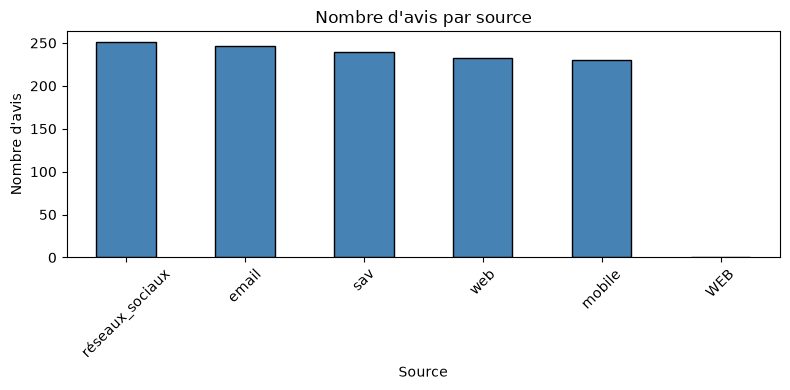

In [17]:
repartition_source = df["source"].value_counts()
print(repartition_source)

plt.figure(figsize=(8, 4))
repartition_source.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Répartition des avis par source

Les 5 sources principales sont globalement équilibrées, entre 230 et 251 avis chacune 
(réseaux_sociaux : 251, email : 247, sav : 239, web : 232, mobile : 230).

À noter : une valeur `WEB` (majuscules) apparaît séparément de `web`, avec 1 seule 
occurrence probablement une erreur de saisie/casse qui dédouble artificiellement 
cette catégorie. À corriger en fusionnant avec `web`.

### 16) Visualiser et commenter le nombre d'avis par produit 

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64


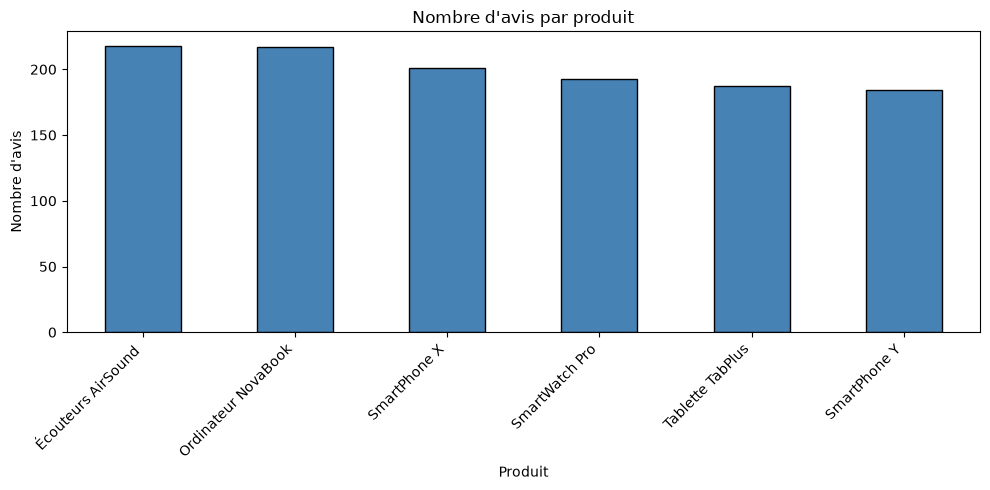

In [18]:
repartition_produit = df["produit"].value_counts()
print(repartition_produit)

plt.figure(figsize=(10, 5))
repartition_produit.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Nombre d'avis par produit")
plt.xlabel("Produit")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Répartition des avis par produit

6 produits sont représentés dans le dataset, avec une répartition équilibrée : 

Écouteurs AirSound (218), Ordinateur NovaBook (217), SmartPhone X (201),

SmartWatch Pro (193), Tablette TabPlus (187), SmartPhone Y (184). 

Aucun produit ne domine ni n'est sous-représenté de façon problématique.

## Partie 2 – Nettoyage 

### 1) Supprimer les lignes contenant des valeurs manquantes de texte 

In [19]:
print(f"Nombre de lignes avant suppression : {len(df)}")

df = df[~(df["texte"].isnull() | (df["texte"].str.strip() == ""))]
df = df.reset_index(drop=True)

print(f"Nombre de lignes après suppression : {len(df)}")

Nombre de lignes avant suppression : 1200
Nombre de lignes après suppression : 1194


### 2) Supprimer les doublons 

In [20]:
print(f"Nombre de lignes avant suppression des doublons : {len(df)}")

df = df.drop_duplicates(subset="texte", keep="first")
df = df.reset_index(drop=True)

print(f"Nombre de lignes après suppression des doublons : {len(df)}")

Nombre de lignes avant suppression des doublons : 1194
Nombre de lignes après suppression des doublons : 317


### 3) Supprimer les URLs 

In [21]:
df["texte_clean"] = df["texte"].str.replace(r"http\S+", "", regex=True)

# Vérification sur un exemple qui contenait une URL
print(df.loc[df["texte"].str.contains(r"http\S+", na=False), ["texte", "texte_clean"]].head(3))

                                                texte  \
15  Produit parfait, rien à signaler. https://exam...   
27  Très bonne expérience, simple et efficace. htt...   
28  Je viens de recevoir le produit, à voir dans l...   

                                          texte_clean  
15                 Produit parfait, rien à signaler.   
27        Très bonne expérience, simple et efficace.   
28  Je viens de recevoir le produit, à voir dans l...  


### 4) Traiter les mentions et hashtags avec la stratégie la plus pertinente pour une classification de sentiment 

In [22]:
# Suppression complète des mentions (@quelquechose)
df["texte_clean"] = df["texte_clean"].str.replace(r"@\w+", "", regex=True)

# Hashtags : on garde le mot, on retire juste le symbole #
df["texte_clean"] = df["texte_clean"].str.replace(r"#(\w+)", r"\1", regex=True)

# Vérification
print(df.loc[df["texte"].str.contains(r"@\w+|#\w+", na=False), ["texte", "texte_clean"]].head(5))

                                                texte  \
1                 Très satisfait de mon achat 👍 #avis   
9   @client Livraison rapide et produit conforme à...   
11  La batterie tient vraiment bien et l'écran est...   
14               Produit correct pour son prix. #avis   
29  @client Service client réactif et commande reç...   

                                          texte_clean  
1                  Très satisfait de mon achat 👍 avis  
9    Livraison rapide et produit conforme à mes at...  
11  La batterie tient vraiment bien et l'écran est...  
14                Produit correct pour son prix. avis  
29   Service client réactif et commande reçue rapi...  


### 5) Nettoyer les espaces 

In [23]:
df["texte_clean"] = df["texte_clean"].str.replace(r"\s+", " ", regex=True).str.strip()

# Vérification sur quelques exemples
df[["texte", "texte_clean"]].head(5)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !!!"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...


### 6) Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment 

In [24]:
df["texte_clean"] = df["texte_clean"].str.replace(r"[^\w\s]", " ", regex=True)
df["texte_clean"] = df["texte_clean"].str.replace(r"\s+", " ", regex=True).str.strip()

# Vérification
df[["texte", "texte_clean"]].head(5)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...


### 7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus  

In [25]:
def nettoyer_texte(texte):
    """
    Nettoie un texte d'avis client :
    - supprime les URLs
    - supprime les mentions (@quelquechose)
    - extrait le mot des hashtags (#quelquechose -> quelquechose)
    - supprime la ponctuation
    - normalise les espaces
    """
    texte = re.sub(r"http\S+", "", texte)
    texte = re.sub(r"@\w+", "", texte)
    texte = re.sub(r"#(\w+)", r"\1", texte)
    texte = re.sub(r"[^\w\s]", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

# Test rapide sur un exemple contenant plusieurs problèmes à la fois
exemple = "Très  satisfait!! @client voir https://ex.com #top 😊"
print(nettoyer_texte(exemple))

Très satisfait voir top


### 8) Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus 

In [26]:
df["texte_clean"] = df["texte"].apply(nettoyer_texte)

print(f"Nombre de lignes traitées : {len(df)}")
df[["texte", "texte_clean"]].head(5)

Nombre de lignes traitées : 317


,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST...


### 9) Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations 

In [27]:
pd.set_option("display.max_colwidth", None)
df[["texte", "texte_clean"]].head(10)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST SUPERBE
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT
7,Très satisfait de mon achat 👍,Très satisfait de mon achat
8,Le produit correspond globalement à la description.,Le produit correspond globalement à la description
9,@client Livraison rapide et produit conforme à mes attentes.,Livraison rapide et produit conforme à mes attentes


## Partie 3 – Tokenisation 

### 1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ? 

`split()` découpe uniquement sur les espaces, de façon purement mécanique. Il ne gère 
pas correctement la ponctuation collée aux mots, les contractions (ex. "l'écran"), les 
mots composés avec tiret, ou les règles spécifiques à une langue. Un vrai tokenizer 
(comme celui de NLTK) applique des règles linguistiques pour produire des tokens plus 
justes et cohérents.

### 2) Utiliser la bibliothèque NLTK pour déterminer : 

#### a) le nombre de tokens de chaque texte, 

In [28]:
import nltk
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize

# a) Nombre de tokens de chaque texte
df["nb_tokens"] = df["texte_clean"].apply(lambda t: len(word_tokenize(t, language="french")))
df[["texte_clean", "nb_tokens"]].head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/diamata/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,texte_clean,nb_tokens
0,Très bonne expérience simple et efficace,6
1,Très satisfait de mon achat avis,6
2,Produit parfait rien à signaler,5
3,Produit excellent je suis très satisfait,6
4,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST SUPERBE,10


#### b) nombre moyen de tokens ; 

In [29]:
nb_tokens_moyen = df["nb_tokens"].mean()
print(f"Nombre moyen de tokens : {nb_tokens_moyen:.2f}")

Nombre moyen de tokens : 7.00


#### c) texte avec le plus grand nombre de tokens ; 

In [30]:
texte_max_tokens = df.loc[df["nb_tokens"].idxmax(), "texte_clean"]
print(f"Texte avec le plus de tokens ({df['nb_tokens'].max()} tokens) :\n{texte_max_tokens}")

Texte avec le plus de tokens (120 tokens) :
Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue Le produit est bien mais la livraison a été longue


#### d) texte avec le plus petit nombre de tokens. 

In [31]:
texte_min_tokens = df.loc[df["nb_tokens"].idxmin(), "texte_clean"]
print(f"Texte avec le moins de tokens ({df['nb_tokens'].min()} tokens) :\n{texte_min_tokens}")

Texte avec le moins de tokens (1 tokens) :
OK


## Partie 4 – Normalisation 

### 1) Uniformiser la casse en minuscules. Pourquoi ce traitement ?

In [32]:
df["texte_clean"] = df["texte_clean"].str.lower()

df[["texte", "texte_clean"]].head(5)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.",produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,la batterie tient vraiment bien et l écran est superbe


#### Uniformisation de la casse

Convertir tout le texte en minuscules évite que des mots identiques en sens (ex. 
"Excellent" et "excellent") soient comptés comme deux mots différents lors de la 
vectorisation (Bag of Words, TF-IDF), ce qui fausserait les statistiques et gonflerait 
inutilement le vocabulaire.

### 2) Faut-il systématiquement supprimer les accents dans un corpus français ? 

Non, ce n'est pas recommandé par défaut en français : les accents portent du sens 
("a" vs "à", "ou" vs "où") et les supprimer risquerait de fusionner des mots différents. 
Ce traitement peut se justifier ponctuellement si le corpus contient beaucoup de fautes 
de frappe/variantes d'accentuation (ex. "tres" vs "très"), pour unifier ces variantes, 
mais au prix d'une perte de précision sémantique ailleurs. Dans cet atelier, on choisit 
de **conserver les accents**.

### 3) Quels stop words supprimer ?

In [33]:
nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words_fr = set(stopwords.words("french"))
print(f"Nombre de stop words (liste standard NLTK) : {len(stop_words_fr)}")
print(sorted(stop_words_fr))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/diamata/nltk_data...


Nombre de stop words (liste standard NLTK) : 157
['ai', 'aie', 'aient', 'aies', 'ait', 'as', 'au', 'aura', 'aurai', 'auraient', 'aurais', 'aurait', 'auras', 'aurez', 'auriez', 'aurions', 'aurons', 'auront', 'aux', 'avaient', 'avais', 'avait', 'avec', 'avez', 'aviez', 'avions', 'avons', 'ayant', 'ayante', 'ayantes', 'ayants', 'ayez', 'ayons', 'c', 'ce', 'ces', 'd', 'dans', 'de', 'des', 'du', 'elle', 'en', 'es', 'est', 'et', 'eu', 'eue', 'eues', 'eurent', 'eus', 'eusse', 'eussent', 'eusses', 'eussiez', 'eussions', 'eut', 'eux', 'eûmes', 'eût', 'eûtes', 'furent', 'fus', 'fusse', 'fussent', 'fusses', 'fussiez', 'fussions', 'fut', 'fûmes', 'fût', 'fûtes', 'il', 'ils', 'j', 'je', 'l', 'la', 'le', 'les', 'leur', 'lui', 'm', 'ma', 'mais', 'me', 'mes', 'moi', 'mon', 'même', 'n', 'ne', 'nos', 'notre', 'nous', 'on', 'ont', 'ou', 'par', 'pas', 'pour', 'qu', 'que', 'qui', 's', 'sa', 'se', 'sera', 'serai', 'seraient', 'serais', 'serait', 'seras', 'serez', 'seriez', 'serions', 'serons', 'seront', 'se

[nltk_data]   Unzipping corpora/stopwords.zip.


### 4) Quels stop words conserver ? 

In [34]:
negations_a_conserver = {"ne", "pas", "plus", "jamais", "rien", "aucun", "aucune", "sans", "ni"}

stop_words_fr_final = stop_words_fr - negations_a_conserver

print(f"Stop words avant : {len(stop_words_fr)}")
print(f"Stop words après exclusion des négations : {len(stop_words_fr_final)}")
print("Mots conservés (négations) :", sorted(negations_a_conserver & stop_words_fr))

Stop words avant : 157
Stop words après exclusion des négations : 155
Mots conservés (négations) : ['ne', 'pas']


Les mots de négation (ne, pas, plus, jamais, rien, aucun, sans...) doivent être 
**conservés**, même s'ils font partie de la liste standard des stop words. Les supprimer 
inverserait le sens d'une phrase pour la classification de sentiment (ex. "pas content" 
deviendrait juste "content"). Tous les autres stop words (articles, pronoms, auxiliaires...) 
sont supprimés sans risque, car ils ne portent pas d'information de sentiment.

### 5) Appliquer la technique (stemming ou lemmatisation) la plus adaptée ? 

In [35]:
import spacy

nlp = spacy.load("fr_core_news_sm")

def lemmatiser_texte(texte):
    doc = nlp(texte)
    tokens_gardes = [
        token.lemma_ for token in doc
        if token.text not in stop_words_fr_final
    ]
    return " ".join(tokens_gardes)

# Test rapide
exemple = "je n étais pas très satisfaite des produits reçus"
print(lemmatiser_texte(exemple))

pas très satisfait produit recevoir


### Stemming ou lemmatisation ?

Le **stemming** tronque les mots de façon mécanique selon des règles simples, sans 
comprendre leur sens (ex. "aimais", "aimé", "aimant" → "aim") rapide, mais le résultat 
n'est souvent pas un vrai mot et peut fusionner des mots de sens différent.

La **lemmatisation** ramène chaque mot à sa forme "dictionnaire" (infinitif pour un 
verbe, masculin singulier pour un adjectif) grâce à une vraie analyse linguistique 
(ex. "aimais", "aimé", "aimant" → "aimer") plus précis et plus lisible.

**Choix retenu : la lemmatisation**, via spaCy (`fr_core_news_sm`), car elle est mieux 
adaptée au français que le stemming (surtout conçu pour l'anglais) et donne des résultats 
plus fiables pour une analyse de sentiment où la nuance du mot compte.

### 6) Stocker sur une colonne « texte_final », les textes ayant subi le nettoyage et les traitements ci-dessus 

In [36]:
df["texte_final"] = df["texte_clean"].apply(lemmatiser_texte)

df[["texte_clean", "texte_final"]].head(5)

,texte_clean,texte_final
0,très bonne expérience simple et efficace,très bon expérience simple efficace
1,très satisfait de mon achat avis,très satisfait achat avis
2,produit parfait rien à signaler,produit parfaire rien signaler
3,produit excellent je suis très satisfait,produit excellent très satisfait
4,la batterie tient vraiment bien et l écran est superbe,batterie tenir vraiment bien écran superbe


### 7) Vérifier le contenu des colonnes texte, texte_clean et texte_final sur les 10 premières observations 

In [37]:
pd.set_option("display.max_colwidth", None)
df[["texte", "texte_clean", "texte_final"]].head(10)

,texte,texte_clean,texte_final
0,"Très bonne expérience, simple et efficace.",très bonne expérience simple et efficace,très bon expérience simple efficace
1,Très satisfait de mon achat 👍 #avis,très satisfait de mon achat avis,très satisfait achat avis
2,"Produit parfait, rien à signaler.",produit parfait rien à signaler,produit parfaire rien signaler
3,"Produit excellent, je suis très satisfait. !!!",produit excellent je suis très satisfait,produit excellent très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,la batterie tient vraiment bien et l écran est superbe,batterie tenir vraiment bien écran superbe
5,Très satisfait de mon achat 👍 😊,très satisfait de mon achat,très satisfait achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.,service client réactif et commande reçue rapidement,service client réactif commande recevoir rapidement
7,Très satisfait de mon achat 👍,très satisfait de mon achat,très satisfait achat
8,Le produit correspond globalement à la description.,le produit correspond globalement à la description,produit correspondre globalement description
9,@client Livraison rapide et produit conforme à mes attentes.,livraison rapide et produit conforme à mes attentes,livraison rapide produire conforme attente


### Limite observée de la lemmatisation

Sur quelques cas, spaCy lemmatise incorrectement des mots ambigus entre nom et verbe 
(ex. "parfait" → "parfaire", "produit" → "produire" au lieu de rester "produit"). 
C'est une limite connue de la lemmatisation automatique sur des phrases courtes sans 
contexte suffisant pour désambiguïser.

### 8) Sauvegarder le dataset nettoyé dans le fichier smart_reviews_cleaned.csv

In [38]:
colonnes_finales = ["id_avis", "date", "source", "produit", "texte", "texte_clean", "texte_final", "sentiment", "note", "langue"]

df_export = df[colonnes_finales]

df_export.to_csv("../data/smart_reviews_cleaned.csv", index=False)

print(f"Fichier sauvegardé : {len(df_export)} lignes, {len(df_export.columns)} colonnes")
df_export.head(3)

Fichier sauvegardé : 317 lignes, 10 colonnes


,id_avis,date,source,produit,texte,texte_clean,texte_final,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",très bonne expérience simple et efficace,très bon expérience simple efficace,positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,très satisfait de mon achat avis,très satisfait achat avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",produit parfait rien à signaler,produit parfaire rien signaler,positif,4,fr


## Partie 5 – Découpage Train/Test

Diviser en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que dans les données d'origine. 

In [39]:
from sklearn.model_selection import train_test_split

X = df["texte_final"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Taille train : {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Taille test : {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print("\nProportions dans train :")
print(y_train.value_counts(normalize=True).round(3))
print("\nProportions dans test :")
print(y_test.value_counts(normalize=True).round(3))

Taille train : 253 (79.8%)
Taille test : 64 (20.2%)

Proportions dans train :
sentiment
positif    0.502
negatif    0.249
neutre     0.249
Name: proportion, dtype: float64

Proportions dans test :
sentiment
positif    0.50
negatif    0.25
neutre     0.25
Name: proportion, dtype: float64


### Découpage Train/Test

Split stratifié à 80/20 (79.8%/20.2%), avec conservation des proportions de classes 
entre train et test (positif ~50%, negatif ~25%, neutre ~25%). Ces proportions diffèrent 
de celles observées en Partie 1 sur le dataset brut (positif 64.67%, neutre 20.50%, 
negatif 14.83%) : la déduplication a modifié l'équilibre des classes, le corpus final 
est plus équilibré qu'à l'origine.

## Partie 6 – Vectorisation

### 1) Utiliser la technique « Bag of Words » pour générer et afficher la taille et un extrait du vocabulaire ainsi qu’un morceau de la matrice 

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

vocabulaire_bow = bow_vectorizer.get_feature_names_out()
print(f"Taille du vocabulaire (BoW) : {len(vocabulaire_bow)}")
print(f"Extrait du vocabulaire : {list(vocabulaire_bow[:15])}")
print(f"\nForme de la matrice train : {X_train_bow.shape}")
print(f"\nExtrait de la matrice (5 premières lignes, 10 premières colonnes) :")
print(X_train_bow[:5, :10].toarray())

Taille du vocabulaire (BoW) : 76
Extrait du vocabulaire : ['achat', 'assez', 'attente', 'avi', 'avir', 'avis', 'avoir', 'batterie', 'beaucoup', 'bien', 'bon', 'client', 'commande', 'conforme', 'correct']

Forme de la matrice train : (253, 76)

Extrait de la matrice (5 premières lignes, 10 premières colonnes) :
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


### 2) Utiliser la technique « TF-IDF » pour générer et afficher la taille et un extrait du vocabulaire ainsi qu’un morceau de la matrice 

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

vocabulaire_tfidf = tfidf_vectorizer.get_feature_names_out()
print(f"Taille du vocabulaire (TF-IDF) : {len(vocabulaire_tfidf)}")
print(f"Extrait du vocabulaire : {list(vocabulaire_tfidf[:15])}")
print(f"\nForme de la matrice train : {X_train_tfidf.shape}")
print(f"\nExtrait de la matrice (5 premières lignes, 10 premières colonnes) :")
print(X_train_tfidf[:5, :10].toarray().round(2))

Taille du vocabulaire (TF-IDF) : 76
Extrait du vocabulaire : ['achat', 'assez', 'attente', 'avi', 'avir', 'avis', 'avoir', 'batterie', 'beaucoup', 'bien', 'bon', 'client', 'commande', 'conforme', 'correct']

Forme de la matrice train : (253, 76)

Extrait de la matrice (5 premières lignes, 10 premières colonnes) :
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.38 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]


### 3) Utiliser la technique « TF-IDF avec des unigrams et bigrams » pour générer et afficher la taille et un extrait du vocabulaire ainsi qu’un morceau de la matrice 

In [42]:
tfidf_bigram_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(X_train)
X_test_tfidf_bigram = tfidf_bigram_vectorizer.transform(X_test)

vocabulaire_bigram = tfidf_bigram_vectorizer.get_feature_names_out()
print(f"Taille du vocabulaire (TF-IDF unigrams+bigrams) : {len(vocabulaire_bigram)}")
print(f"Extrait du vocabulaire : {list(vocabulaire_bigram[:15])}")
print(f"\nForme de la matrice train : {X_train_tfidf_bigram.shape}")
print(f"\nExtrait de la matrice (5 premières lignes, 10 premières colonnes) :")
print(X_train_tfidf_bigram[:5, :10].toarray().round(2))

Taille du vocabulaire (TF-IDF unigrams+bigrams) : 186
Extrait du vocabulaire : ['achat', 'achat avis', 'assez', 'assez simple', 'attente', 'attente avis', 'avi', 'avir', 'avis', 'avoir', 'avoir long', 'avoir longue', 'avoir pas', 'avoir très', 'avoir trèèès']

Forme de la matrice train : (253, 186)

Extrait de la matrice (5 premières lignes, 10 premières colonnes) :
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.27]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]


### 4) Comparer les trois techniques 

| Aspect | Bag of Words | TF-IDF | TF-IDF (uni+bigrams) |
|---|---|---|---|
| Taille du vocabulaire | 76 | 76 | 186 |
| Type de valeurs | Comptages bruts (entiers) | Scores pondérés (0 à 1) | Scores pondérés (0 à 1) |
| Capture l'ordre des mots | Non | Non | Partiellement (paires de mots) |
| Gère les négations collées | Non | Non | Oui (ex. "pas satisfait") |

**Bag of Words** est le plus simple, mais traite tous les mots comme également 
importants un mot très fréquent dans tout le corpus (ex. "produit") pèse autant qu'un 
mot rare et discriminant.

**TF-IDF** corrige ce défaut en pondérant chaque mot selon sa rareté relative dans le 
corpus, ce qui donne plus de poids aux mots réellement informatifs pour distinguer les 
avis entre eux.

**TF-IDF avec unigrams + bigrams** va plus loin en capturant des paires de mots comme 
"pas satisfait" ou "très bon", que les deux autres méthodes ne voient qu'en mots séparés. 
C'est particulièrement utile pour le sentiment, où le sens dépend souvent de la 
combinaison de deux mots (une négation + un mot positif, par exemple), pas d'un mot isolé. 
Le prix à payer : un vocabulaire plus grand (186 contre 76), donc une matrice plus creuse 
et plus coûteuse à traiter sur un gros corpus (ici, ça reste négligeable avec seulement 
253 textes en train).

**Technique retenue pour la suite : TF-IDF avec unigrams et bigrams**, le meilleur 
compromis entre richesse d'information et complexité pour ce cas d'usage.